# Python Cheat Sheet for In-Vivo Analysis (Beginner Friendly)

This notebook is for people with **no Python background**.

It teaches the minimum concepts you need to understand and run analysis notebooks in this repository.

## What you will learn
1. Python basics (types, lists, dictionaries)
2. NumPy and slicing 1D arrays
3. Pandas basics
4. Plotting with Matplotlib and Seaborn
5. Accessing napari layers (`Image` and `Labels`)

---

### How to use this notebook
- Run each code cell from top to bottom.
- Read the explanation first, then run code.
- Modify one value at a time to learn safely.

If you get stuck, restart kernel and run all cells again in order.

## 1) Python Basics: Variables, Types, Lists, Dictionaries, Functions, Modules, and Classes

Python stores data in variables.

Common data types:
- `int` -> whole numbers (`3`)
- `float` -> decimal numbers (`3.14`)
- `str` -> text (`"cell"`)
- `bool` -> `True` or `False`

Two structures you will use constantly:
- **List**: ordered collection, e.g. `[1, 2, 3]`
- **Dictionary**: key-value mapping, e.g. `{"animal": "mouse"}`

### Lists: `append()` and list addition
- `my_list.append(x)` adds one new item to the **end** of the same list.
- `list_a + list_b` makes a **new combined list** (it does not modify `list_a` unless you reassign).

Example:
- `a = [1, 2]`
- `a.append(3)` -> `a` becomes `[1, 2, 3]`
- `b = a + [4, 5]` -> `b` is `[1, 2, 3, 4, 5]`

### If/else statements and for loops
- `if/else` lets Python make decisions.
- `for` loops let Python repeat an action over each item in a list.

Very simple idea:
- `if value > threshold:` do one thing
- `else:` do another thing
- `for x in my_list:` repeat code for each `x`

These are core tools in analysis notebooks (for filtering values, labeling active cells, and iterating over ROIs).

### Functions (very important)
A **function** is a reusable block of code that does one job.

Example idea: instead of repeating "compute baseline" in many places, you write one function and call it many times.

### Modules (why `module.something`?)
A **module** is a Python file (or package) that contains functions, classes, or variables.

When you do `import numpy as np`, you loaded the module `numpy` and gave it the short name `np`.
Then `np.mean(...)` means: "use the `mean` function from the `numpy` module".

`module.something` helps because:
- it tells you where code comes from,
- avoids name collisions,
- keeps code organized.

### Classes (very easy intuition)
A **class** is like a blueprint/template.
An **object** is one concrete thing created from that blueprint.

Example intuition:
- Class: "Cell"
- Object: one specific cell with its own ID and trace data.

You use classes when you want to bundle related data + behavior together.

In [1]:
# Basic variables and types
age_days = 21                 # int
sampling_rate_hz = 30.0       # float
sample_name = "mouse_A1"      # str
is_good_recording = True      # bool

print("age_days:", age_days, type(age_days))
print("sampling_rate_hz:", sampling_rate_hz, type(sampling_rate_hz))
print("sample_name:", sample_name, type(sample_name))
print("is_good_recording:", is_good_recording, type(is_good_recording))

# Lists
roi_areas = [120, 98, 143, 110]
print("\nroi_areas:", roi_areas)
print("First ROI area:", roi_areas[0])  # index starts at 0
print("Last ROI area:", roi_areas[-1])

# List append(): modifies the same list by adding one item at the end
roi_areas.append(125)
print("After roi_areas.append(125):", roi_areas)

# List addition (+): creates a new combined list
extra_areas = [130, 140]
all_areas = roi_areas + extra_areas
print("extra_areas:", extra_areas)
print("all_areas = roi_areas + extra_areas:", all_areas)
print("roi_areas is still:", roi_areas)

# If/else + for loop example
print("\nIf/else with for loop (threshold = 120):")
threshold = 120
for area in roi_areas:
    if area > threshold:
        print(area, "-> large ROI")
    else:
        print(area, "-> small/medium ROI")

# Dictionaries
metadata = {
    "animal_id": "A1",
    "genotype": "alpha9",
    "frame_rate": 30,
}
print("\nmetadata:", metadata)
print("Animal ID:", metadata["animal_id"])

# Function: reusable code block
def area_to_diameter(area_pixels):
    return (4 * area_pixels / 3.14159) ** 0.5

print("\nFunction example: diameter from area 120 ->", round(area_to_diameter(120), 2))

# Module usage example
import math
print("module.something example (math.sqrt):", math.sqrt(81))

# Very simple class example
class Cell:
    def __init__(self, cell_id, peak_dff):
        self.cell_id = cell_id
        self.peak_dff = peak_dff

    def is_active(self, threshold=0.2):
        return self.peak_dff > threshold

cell_1 = Cell(cell_id="cell_001", peak_dff=0.35)
print("Class example ->", cell_1.cell_id, "active?", cell_1.is_active())

age_days: 21 <class 'int'>
sampling_rate_hz: 30.0 <class 'float'>
sample_name: mouse_A1 <class 'str'>
is_good_recording: True <class 'bool'>

roi_areas: [120, 98, 143, 110]
First ROI area: 120
Last ROI area: 110
After roi_areas.append(125): [120, 98, 143, 110, 125]
extra_areas: [130, 140]
all_areas = roi_areas + extra_areas: [120, 98, 143, 110, 125, 130, 140]
roi_areas is still: [120, 98, 143, 110, 125]

If/else with for loop (threshold = 120):
120 -> small/medium ROI
98 -> small/medium ROI
143 -> large ROI
110 -> small/medium ROI
125 -> large ROI

metadata: {'animal_id': 'A1', 'genotype': 'alpha9', 'frame_rate': 30}
Animal ID: A1

Function example: diameter from area 120 -> 12.36
module.something example (math.sqrt): 9.0
Class example -> cell_001 active? True


## 2) NumPy: Fast Arrays + Slicing (1D and 3D)

NumPy arrays are like lists but faster and designed for numerical operations.

For 1D slicing, remember:
- `arr[start:stop]` includes `start` but excludes `stop`
- `arr[:5]` = first five elements
- `arr[5:]` = from index 5 to end
- `arr[::2]` = every second element

For 3D arrays, think in axes.
In imaging, a movie is often shaped `(nFrames, width, height)`.

Then:
- `movie[0, :, :]` -> first frame
- `movie[:, 20:40, 30:60]` -> all frames, cropped spatial region
- `movie[10:20, :, :]` -> frames 10 to 19 (time window)

In [2]:
import numpy as np

# ----------------------------
# 1D array example (trace)
# ----------------------------
trace = np.array([0.10, 0.13, 0.09, 0.20, 0.25, 0.22, 0.18, 0.30, 0.28, 0.24])

print("1D trace:", trace)
print("length:", len(trace))

print("\n1D slicing examples")
print("First 4 values trace[:4]:", trace[:4])
print("Values from index 4 onward trace[4:]:", trace[4:])
print("Middle values trace[2:7]:", trace[2:7])
print("Every 2nd value trace[::2]:", trace[::2])
print("Last value trace[-1]:", trace[-1])

print("\n1D basic math")
print("Mean:", trace.mean())
print("Max:", trace.max())

high_values = trace[trace > 0.20]
print("Values > 0.20:", high_values)

# ----------------------------
# 3D array example (movie)
# Shape convention here: (nFrames, width, height)
# ----------------------------
movie = np.arange(5 * 4 * 6).reshape(5, 4, 6)
print("\n3D movie shape (nFrames, width, height):", movie.shape)

first_frame = movie[0, :, :]
time_window = movie[1:4, :, :]
spatial_crop_all_frames = movie[:, 1:3, 2:5]

print("first_frame shape movie[0, :, :]:", first_frame.shape)
print("time_window shape movie[1:4, :, :]:", time_window.shape)
print("spatial_crop_all_frames shape movie[:, 1:3, 2:5]:", spatial_crop_all_frames.shape)

print("\nExample value movie[2, 1, 3]:", movie[2, 1, 3])

1D trace: [0.1  0.13 0.09 0.2  0.25 0.22 0.18 0.3  0.28 0.24]
length: 10

1D slicing examples
First 4 values trace[:4]: [0.1  0.13 0.09 0.2 ]
Values from index 4 onward trace[4:]: [0.25 0.22 0.18 0.3  0.28 0.24]
Middle values trace[2:7]: [0.09 0.2  0.25 0.22 0.18]
Every 2nd value trace[::2]: [0.1  0.09 0.25 0.18 0.28]
Last value trace[-1]: 0.24

1D basic math
Mean: 0.199
Max: 0.3
Values > 0.20: [0.25 0.22 0.3  0.28 0.24]

3D movie shape (nFrames, width, height): (5, 4, 6)
first_frame shape movie[0, :, :]: (4, 6)
time_window shape movie[1:4, :, :]: (3, 4, 6)
spatial_crop_all_frames shape movie[:, 1:3, 2:5]: (5, 2, 3)

Example value movie[2, 1, 3]: 57


## 3) Pandas: Tables (DataFrames)

Pandas is used for tabular data (rows and columns), similar to Excel.

You can:
- Create tables
- Select rows/columns
- Filter data
- Compute summary statistics

This is heavily used for experiment metadata and extracted features.

In [3]:
import pandas as pd

# Build a simple dataframe
# Think of each dict entry as a column
results_df = pd.DataFrame({
    "cell_id": [1, 2, 3, 4, 5],
    "peak_dff": [0.35, 0.18, 0.42, 0.27, 0.15],
    "group": ["control", "control", "treated", "treated", "control"],
})

print("DataFrame:")
display(results_df)

print("\nColumn selection results_df['peak_dff']:")
display(results_df["peak_dff"])

print("\nRow filtering: only treated cells")
treated_df = results_df[results_df["group"] == "treated"]
display(treated_df)

print("\nSummary statistics:")
display(results_df.describe(include="all"))

print("\nGroup mean of peak_dff:")
display(results_df.groupby("group")["peak_dff"].mean())

DataFrame:


,cell_id,peak_dff,group
0,1,0.35,control
1,2,0.18,control
2,3,0.42,treated
3,4,0.27,treated
4,5,0.15,control



Column selection results_df['peak_dff']:


0    0.35
1    0.18
2    0.42
3    0.27
4    0.15
Name: peak_dff, dtype: float64


Row filtering: only treated cells


,cell_id,peak_dff,group
2,3,0.42,treated
3,4,0.27,treated



Summary statistics:


,cell_id,peak_dff,group
count,5.000000,5.00000,5
unique,NaN,NaN,2
top,NaN,NaN,control
freq,NaN,NaN,3
mean,3.000000,0.27400,NaN
std,1.581139,0.11327,NaN
min,1.000000,0.15000,NaN
25%,2.000000,0.18000,NaN
50%,3.000000,0.27000,NaN
75%,4.000000,0.35000,NaN



Group mean of peak_dff:


group
control    0.226667
treated    0.345000
Name: peak_dff, dtype: float64

## 4) Matplotlib and Seaborn: Basic Plots

Plots help you quickly understand data.

- **Matplotlib** gives full control.
- **Seaborn** makes statistical plots easier and prettier.

The next cell creates two simple figures (which also act as visual examples/images).

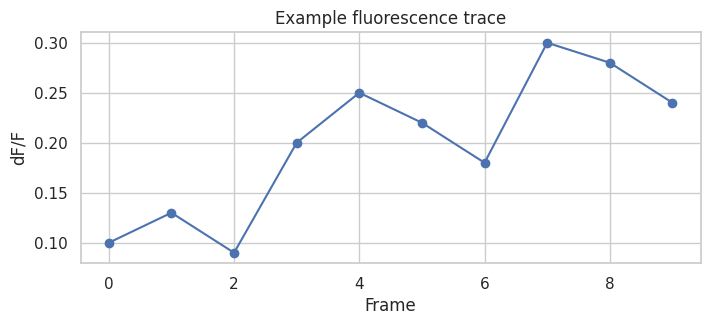

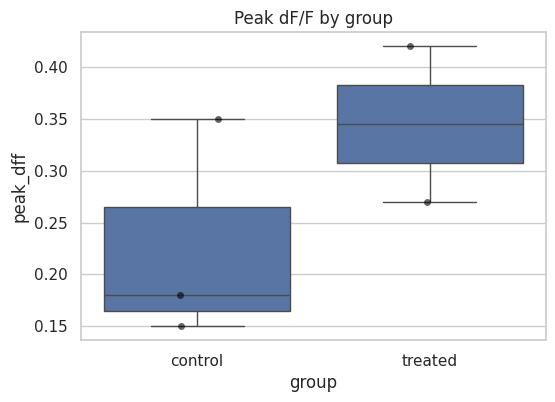

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Example 1: line plot of NumPy trace
plt.figure(figsize=(8, 3))
plt.plot(trace, marker="o")
plt.title("Example fluorescence trace")
plt.xlabel("Frame")
plt.ylabel("dF/F")
plt.show()

# Example 2: seaborn boxplot from pandas dataframe
plt.figure(figsize=(6, 4))
sns.boxplot(data=results_df, x="group", y="peak_dff")
sns.stripplot(data=results_df, x="group", y="peak_dff", color="black", alpha=0.6)
plt.title("Peak dF/F by group")
plt.show()

## 5) Accessing napari Layers (`Image` and `Labels`)

In this project, napari is used to visualize image stacks and segmentation labels.

Typical layer types:
- `Image` layer: grayscale or multichannel imaging data
- `Labels` layer: segmentation masks (integers, where each object has a label ID)

For movies in napari, a common shape convention is:
- `(nFrames, width, height)`

That means axis 0 is time/frame index, and axes 1-2 are spatial dimensions.

The next code creates synthetic data, adds both layers to a napari viewer, and shows how to access layer data and names.

In [5]:
# This cell is safe: if napari is unavailable, it prints a helpful message.
try:
    import napari

    # Synthetic movie with shape (nFrames, width, height)
    # Here: 20 frames, each frame is 128 x 128
    movie = np.random.normal(loc=100, scale=15, size=(20, 128, 128))

    # Synthetic labels with the same shape as movie
    labels = np.zeros((20, 128, 128), dtype=int)
    labels[:, 20:50, 20:50] = 1
    labels[5:15, 70:110, 80:120] = 2

    viewer = napari.Viewer()
    image_layer = viewer.add_image(movie, name="raw_movie")
    labels_layer = viewer.add_labels(labels, name="segmentation")

    print("Movie shape (nFrames, width, height):", movie.shape)
    print("Layer names:", [layer.name for layer in viewer.layers])
    print("Image layer type:", type(image_layer).__name__)
    print("Labels layer type:", type(labels_layer).__name__)
    print("Image layer data shape:", image_layer.data.shape)
    print("Unique label IDs:", np.unique(labels_layer.data))

    # Access a layer later by name
    seg_layer = viewer.layers["segmentation"]
    print("Accessed by name ->", seg_layer.name)

    print("\nClose the napari window when done to continue.")
    napari.run()

except ImportError:
    print("napari is not installed in this environment.")
    print("Install with: pip install napari[all]")
    print("Then re-run this cell.")

Movie shape (nFrames, width, height): (20, 128, 128)
Layer names: ['raw_movie', 'segmentation']
Image layer type: Image
Labels layer type: Labels
Image layer data shape: (20, 128, 128)
Unique label IDs: [0 1 2]
Accessed by name -> segmentation

Close the napari window when done to continue.


## Quick recap

You now know how to:
- Store and organize data in Python variables, lists, and dictionaries
- Slice 1D arrays with NumPy
- Build/filter/summarize tables with pandas
- Make basic plots with matplotlib + seaborn
- Access napari image and label layers programmatically

### Suggested next steps in this repository
1. Open an analysis notebook you care about.
2. Identify where it uses lists, arrays, DataFrames, and layers.
3. Copy small code chunks into this notebook and test them here first.

Learning Python is mostly practice: small edits + rerun + observe output.